In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [2]:
#veriyi okuma ve df ye kaydetme
data="C:\\Users\\Tuncer\\Desktop\\Desktop\\okul\\Yapay_zekaya_giris\\TuncerAlevli_y255050006_Odev2\\Netflix_Binge\\Datasets\\netflix_titles.csv"
df=pd.read_csv(data)
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
#Veriyi anlamak 
print(f"Veri Boyutu:\n {df.shape}")
print(f"info :\n  {df.info()}")
print(f"describe:\n {df.describe(include="all")}")

Veri Boyutu:
 (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
info :
  None
describe:
        show_id   type                 title       director  \
count     8807   8807                  8807           6173   
unique    8807      2                  8807           4528   
top         s1  

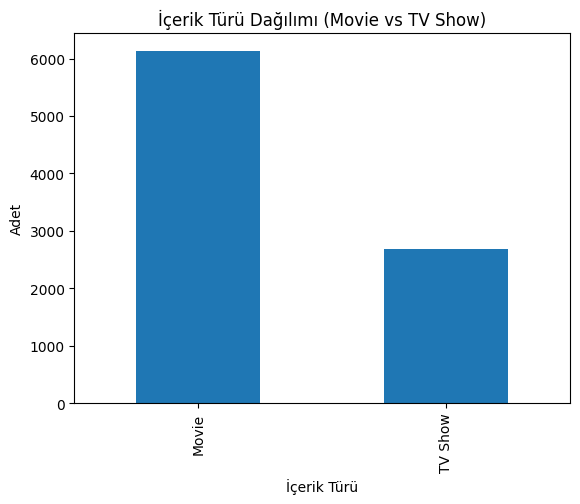

In [4]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")
plt.title("İçerik Türü Dağılımı (Movie vs TV Show)")
plt.xlabel("İçerik Türü")
plt.ylabel("Adet")
plt.show()

In [5]:
df_tv=df[df["type"]=="TV Show"].copy()
df_tv.reset_index(drop=True,inplace=True)
print(f"Yeni Dizi dataframe: \n {df_tv.head(5)}")
dizi_csv=df_tv.to_csv("C:\\Users\\Tuncer\\Desktop\\Desktop\\okul\\Yapay_zekaya_giris\\TuncerAlevli_y255050006_Odev2\\Netflix_Binge\\Datasets\\Diziler.csv")

Yeni Dizi dataframe: 
   show_id     type                  title         director  \
0      s2  TV Show          Blood & Water              NaN   
1      s3  TV Show              Ganglands  Julien Leclercq   
2      s4  TV Show  Jailbirds New Orleans              NaN   
3      s5  TV Show           Kota Factory              NaN   
4      s6  TV Show          Midnight Mass    Mike Flanagan   

                                                cast       country  \
0  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...  South Africa   
1  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...           NaN   
2                                                NaN           NaN   
3  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...         India   
4  Kate Siegel, Zach Gilford, Hamish Linklater, H...           NaN   

           date_added  release_year rating   duration  \
0  September 24, 2021          2021  TV-MA  2 Seasons   
1  September 24, 2021          2021  TV-MA   1 Season   
2  September

In [6]:
#Yeni Veri bilgileri 
print(f"Veri Boyutu:\n {df_tv.shape}")
print(f"info :\n  {df_tv.info()}")
print(f"describe:\n {df_tv.describe(include="all")}")

Veri Boyutu:
 (2676, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2676 entries, 0 to 2675
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       2676 non-null   object
 1   type          2676 non-null   object
 2   title         2676 non-null   object
 3   director      230 non-null    object
 4   cast          2326 non-null   object
 5   country       2285 non-null   object
 6   date_added    2666 non-null   object
 7   release_year  2676 non-null   int64 
 8   rating        2674 non-null   object
 9   duration      2676 non-null   object
 10  listed_in     2676 non-null   object
 11  description   2676 non-null   object
dtypes: int64(1), object(11)
memory usage: 251.0+ KB
info :
  None
describe:
        show_id     type          title             director  \
count     2676     2676           2676                  230   
unique    2676        1           2676                  222   
top         s

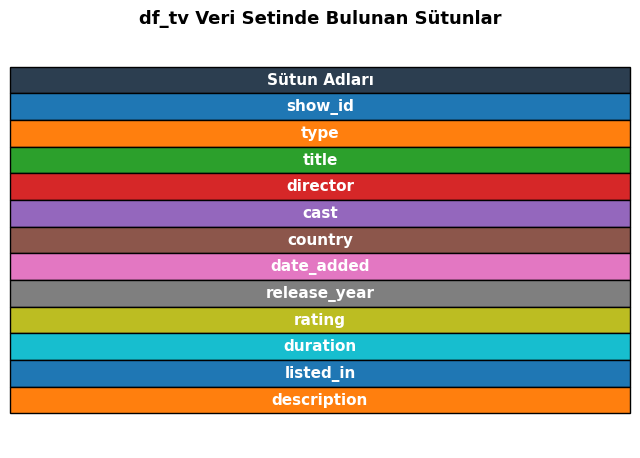

In [7]:
import matplotlib.colors as mcolors

columns = df_tv.columns.tolist()

# Soft ve güzel renk paleti (Tableau + pastel karışımı)
palette = list(mcolors.TABLEAU_COLORS.values())

# Renk sayısı yetmezse döngüyle devam et
colors = [palette[i % len(palette)] for i in range(len(columns))]

fig, ax = plt.subplots(figsize=(8, len(columns) * 0.45))
ax.axis('off')

table_data = [[col] for col in columns]

table = ax.table(
    cellText=table_data,
    colLabels=["Sütun Adları"],
    cellLoc='center',
    loc='center'
)

# Başlık hücresi
table[(0, 0)].set_facecolor("#2c3e50")
table[(0, 0)].get_text().set_color("white")
table[(0, 0)].get_text().set_fontweight("bold")

# Satırları renklendir + yazıyı beyaz yap
for i in range(len(columns)):
    cell = table[(i + 1, 0)]
    cell.set_facecolor(colors[i])
    cell.get_text().set_color("white")
    cell.get_text().set_fontweight("bold")

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

plt.title("df_tv Veri Setinde Bulunan Sütunlar", fontsize=13, fontweight="bold")
plt.show()


In [ ]:
columns_to_drop=[
    "show_id",
    "type",
    "director",
    "cast",
    "country",
    "date_added",
    "description"
]
df_tv_clean=df_tv.drop(columns=columns_to_drop)
dizi_csv=df_tv_clean.to_csv("C:\\Users\\Tuncer\\Desktop\\Desktop\\okul\\Yapay_zekaya_giris\\TuncerAlevli_y255050006_Odev2\\Netflix_Binge\\Datasets\\Diziler.csv")
table_df = df_tv_clean.head(5)

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='center',
    loc='center'
)

# Yazı ayarları
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# 🔑 Sütun genişliklerini içeriğe göre ayarla
for i, col in enumerate(table_df.columns):
    max_len = max(
        table_df[col].astype(str).map(len).max(),        len(col)
    )
    table.auto_set_column_width(i)

# Başlık stil
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")

plt.title("Temizlenmiş Dizi Veri Seti (İlk 5 Kayıt)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
print("Temiz veri boyutu:", df_tv_clean.shape)

Temiz veri boyutu: (2676, 5)


In [10]:
df_tv_clean["num_seasons"] = (
    df_tv_clean["duration"]
    .str.extract(r"(\d+)")
    .astype(int)
)
df_tv_clean[["duration", "num_seasons"]].head(10)


,duration,num_seasons
0,2 Seasons,2
1,1 Season,1
2,1 Season,1
3,2 Seasons,2
4,1 Season,1
5,9 Seasons,9
6,1 Season,1
7,1 Season,1
8,1 Season,1
9,4 Seasons,4


In [11]:
df_tv_clean.drop(columns=["duration"], inplace=True)

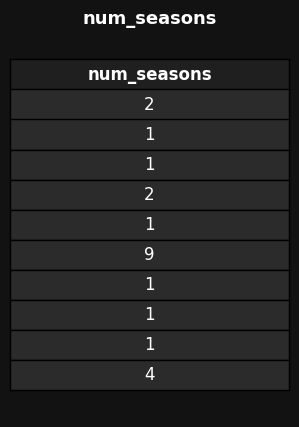

In [12]:
import matplotlib.pyplot as plt

# İlk 10 değeri al (index kullanmadan)
values = df_tv_clean["num_seasons"].head(10).values.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(3, 5))
ax.axis('off')

table = ax.table(
    cellText=values,
    colLabels=["num_seasons"],
    cellLoc='center',
    loc='center'
)

# Genel stil
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Başlık stili
table[(0, 0)].set_facecolor("#1f1f1f")
table[(0, 0)].get_text().set_color("white")
table[(0, 0)].get_text().set_fontweight("bold")

# Hücre stili (görseldeki gibi koyu ton)
for i in range(1, len(values) + 1):
    cell = table[(i, 0)]
    cell.set_facecolor("#2b2b2b")
    cell.get_text().set_color("white")

plt.title("num_seasons", fontsize=13, fontweight="bold", color="white")
fig.patch.set_facecolor("#121212")  # Arka plan koyu
plt.show()


In [13]:
print(df_tv_clean.head(5))

                   title  release_year rating  \
0          Blood & Water          2021  TV-MA   
1              Ganglands          2021  TV-MA   
2  Jailbirds New Orleans          2021  TV-MA   
3           Kota Factory          2021  TV-MA   
4          Midnight Mass          2021  TV-MA   

                                           listed_in  num_seasons  
0    International TV Shows, TV Dramas, TV Mysteries            2  
1  Crime TV Shows, International TV Shows, TV Act...            1  
2                             Docuseries, Reality TV            1  
3  International TV Shows, Romantic TV Shows, TV ...            2  
4                 TV Dramas, TV Horror, TV Mysteries            1  


In [14]:
df_tv_clean[["release_year", "num_seasons"]].isnull().sum()

release_year    0
num_seasons     0
dtype: int64

In [15]:
print(df_tv_clean.isnull().sum())

title           0
release_year    0
rating          2
listed_in       0
num_seasons     0
dtype: int64


In [16]:
df_tv_clean = df_tv_clean.dropna(subset=["rating"])
df_tv_clean.reset_index(drop=True, inplace=True)


In [17]:
df_tv_clean["is_mature"] = df_tv_clean["rating"].apply(
    lambda x: 1 if x in ["TV-MA", "R", "NC-17"] else 0
)
df_tv_clean[["rating", "is_mature"]].head(10)
print(df_tv_clean["is_mature"].value_counts())
df_tv_clean.reset_index(drop=True, inplace=True)
dizi_csv=df_tv_clean.to_csv("C:\\Users\\Tuncer\\Desktop\\Desktop\\okul\\Yapay_zekaya_giris\\TuncerAlevli_y255050006_Odev2\\Netflix_Binge\\Datasets\\Diziler.csv",
                            index=False)




is_mature
0    1527
1    1147
Name: count, dtype: int64


In [18]:
df_tv_clean["genre_count"] = df_tv_clean["listed_in"].apply(
    lambda x: len(x.split(","))
)


In [19]:
df_tv_clean[["listed_in", "genre_count"]].head()


,listed_in,genre_count
0,"International TV Shows, TV Dramas, TV Mysteries",3
1,"Crime TV Shows, International TV Shows, TV Act...",3
2,"Docuseries, Reality TV",2
3,"International TV Shows, Romantic TV Shows, TV ...",3
4,"TV Dramas, TV Horror, TV Mysteries",3


In [20]:
df_tv_clean.drop(columns=["listed_in"], inplace=True)
print(df_tv_clean.head(5))

                   title  release_year rating  num_seasons  is_mature  \
0          Blood & Water          2021  TV-MA            2          1   
1              Ganglands          2021  TV-MA            1          1   
2  Jailbirds New Orleans          2021  TV-MA            1          1   
3           Kota Factory          2021  TV-MA            2          1   
4          Midnight Mass          2021  TV-MA            1          1   

   genre_count  
0            3  
1            3  
2            2  
3            3  
4            3  


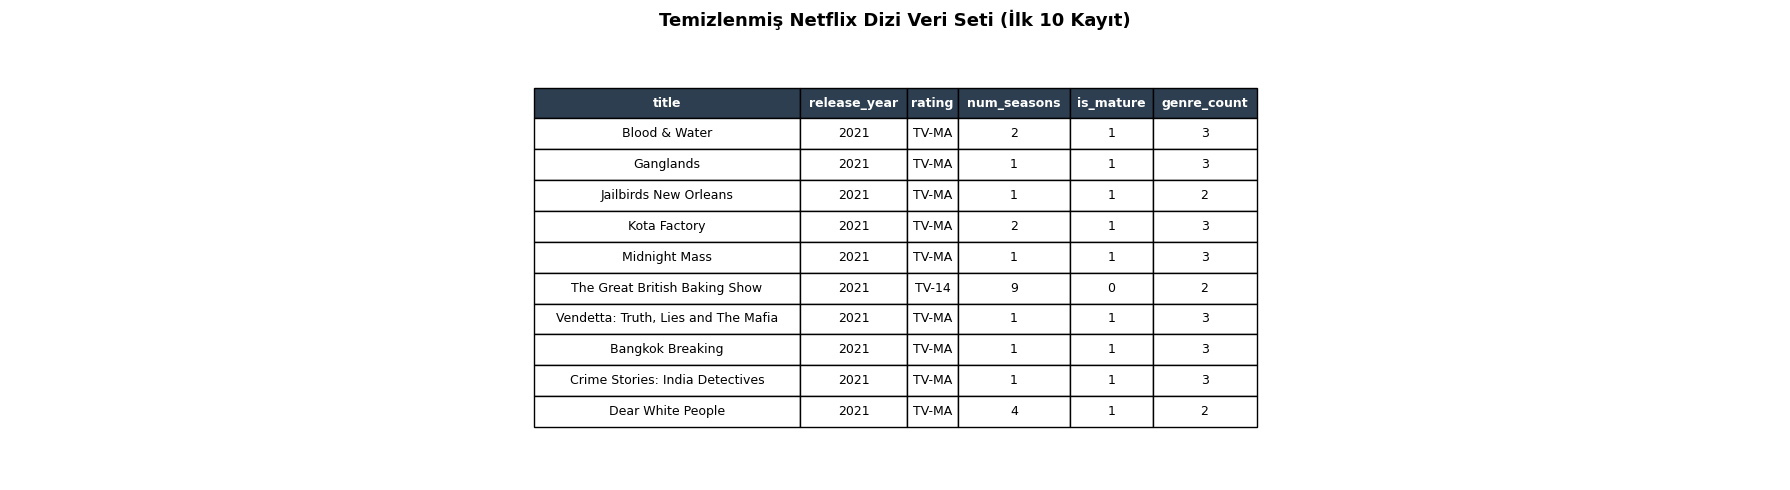

In [21]:
# İlk 10 satır
table_df = df_tv_clean.head(10)

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='center',
    loc='center'
)

# Yazı ve ölçek ayarları
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# 🔑 Sütun genişliklerini otomatik ayarla
for i in range(len(table_df.columns)):
    table.auto_set_column_width(i)

# Başlık satırı stil
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")

plt.title(
    "Temizlenmiş Netflix Dizi Veri Seti (İlk 10 Kayıt)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
dizi_csv=df_tv_clean.to_csv("C:\\Users\\Tuncer\\Desktop\\Desktop\\okul\\Yapay_zekaya_giris\\TuncerAlevli_y255050006_Odev2\\Netflix_Binge\\Datasets\\Diziler.csv",
                            index=False)


In [22]:
df_tv_clean["binge_score"] = (
    df_tv_clean["num_seasons"] * 0.5 +
    df_tv_clean["genre_count"] * 0.3 +
    df_tv_clean["is_mature"] * 0.2
)


In [23]:
df_tv_clean[["num_seasons", "genre_count", "is_mature", "binge_score"]].head(10)

,num_seasons,genre_count,is_mature,binge_score
0,2,3,1,2.1
1,1,3,1,1.6
2,1,2,1,1.3
3,2,3,1,2.1
4,1,3,1,1.6
5,9,2,0,5.1
6,1,3,1,1.6
7,1,3,1,1.6
8,1,3,1,1.6
9,4,2,1,2.8


In [24]:
dizi_csv=df_tv_clean.to_csv("C:\\Users\\Tuncer\\Desktop\\Desktop\\okul\\Yapay_zekaya_giris\\TuncerAlevli_y255050006_Odev2\\Netflix_Binge\\Datasets\\Diziler.csv",
                            index=False)

In [25]:
df_tv_clean["binge_score"].describe()

count    2674.000000
mean        1.656171
std         0.816222
min         0.800000
25%         1.300000
50%         1.400000
75%         1.800000
max         9.100000
Name: binge_score, dtype: float64

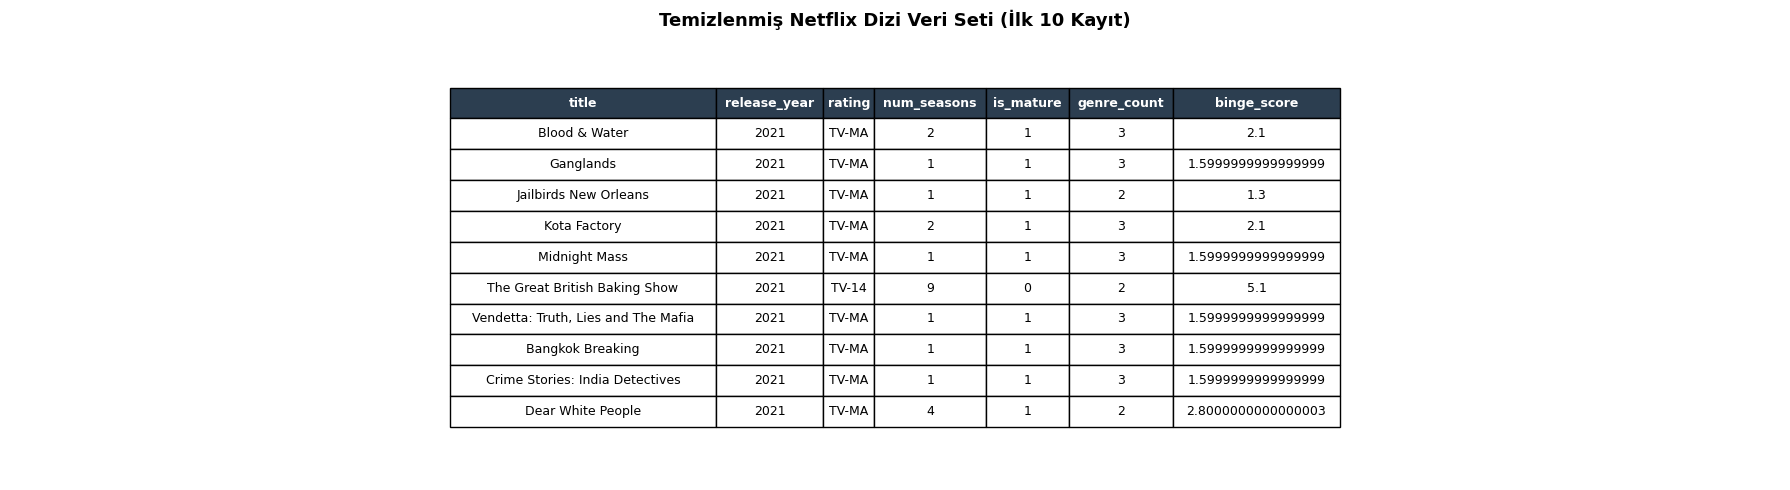

In [26]:
# İlk 10 satır
table_df = df_tv_clean.head(10)

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='center',
    loc='center'
)

# Yazı ve ölçek ayarları
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# 🔑 Sütun genişliklerini otomatik ayarla
for i in range(len(table_df.columns)):
    table.auto_set_column_width(i)

# Başlık satırı stil
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")

plt.title(
    "Temizlenmiş Netflix Dizi Veri Seti (İlk 10 Kayıt)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [27]:
model_features = [
    "num_seasons",
    "release_year",
    "genre_count",
    "is_mature",
    "binge_score"
]

X = df_tv_clean[model_features]
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
print("Ortalama:", X_scaled.mean(axis=0))
print("Standart Sapma:", X_scaled.std(axis=0))


Ortalama: [ 7.44023807e-17 -1.08627476e-14  6.11162413e-17 -9.56602038e-17
 -1.22232483e-16]
Standart Sapma: [1. 1. 1. 1. 1.]


In [29]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_tv_clean["cluster"] = kmeans.fit_predict(X_scaled)

In [30]:
cluster_summary = (
    df_tv_clean
    .groupby("cluster")[model_features]
    .mean()
    .round(2)
)

cluster_summary


,num_seasons,release_year,genre_count,is_mature,binge_score
cluster,,,,,
0,5.94,2014.72,2.24,0.35,3.71
1,1.29,2016.12,2.57,0.00,1.42
2,1.36,2018.01,2.70,1.00,1.69
3,1.55,2015.82,1.00,0.25,1.12


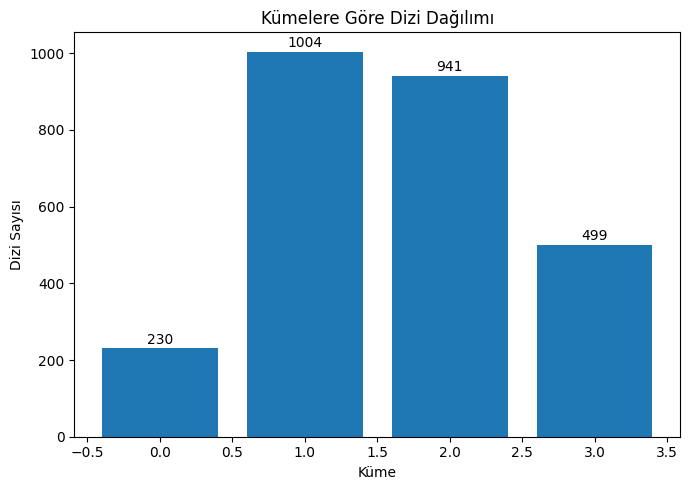

In [31]:
cluster_counts = df_tv_clean["cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))
bars = plt.bar(
    cluster_counts.index,
    cluster_counts.values
)

plt.xlabel("Küme")
plt.ylabel("Dizi Sayısı")
plt.title("Kümelere Göre Dizi Dağılımı")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval),
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


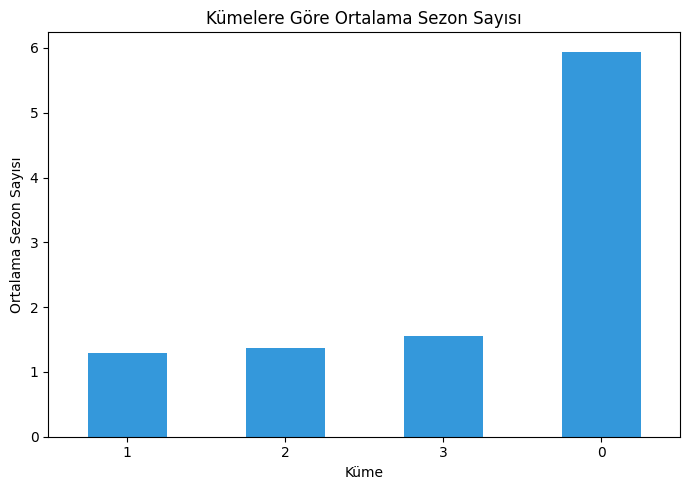

In [32]:
avg_seasons = (
    df_tv_clean
    .groupby("cluster")["num_seasons"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(7,5))
avg_seasons.plot(kind="bar", color="#3498db")

plt.ylabel("Ortalama Sezon Sayısı")
plt.xlabel("Küme")
plt.title("Kümelere Göre Ortalama Sezon Sayısı")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

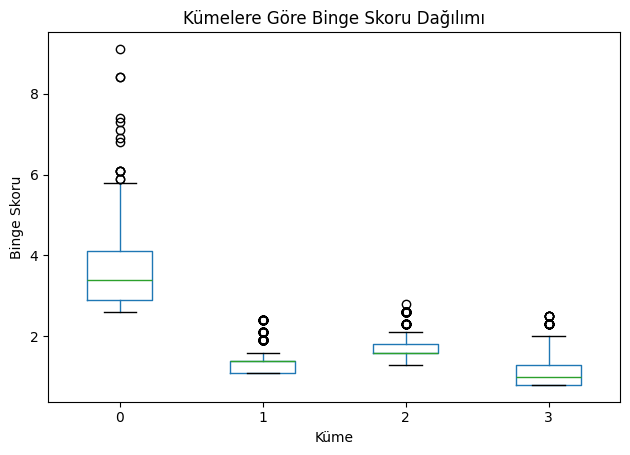

In [ ]:
plt.figure(figsize=(8,5))

df_tv_clean.boxplot(
    column="binge_score",
    by="cluster",
    grid=False
)

plt.title("Kümelere Göre Binge Skoru Dağılımı")
plt.suptitle("")
plt.xlabel("Küme")
plt.ylabel("Binge Skoru")

plt.tight_layout()
plt.show()


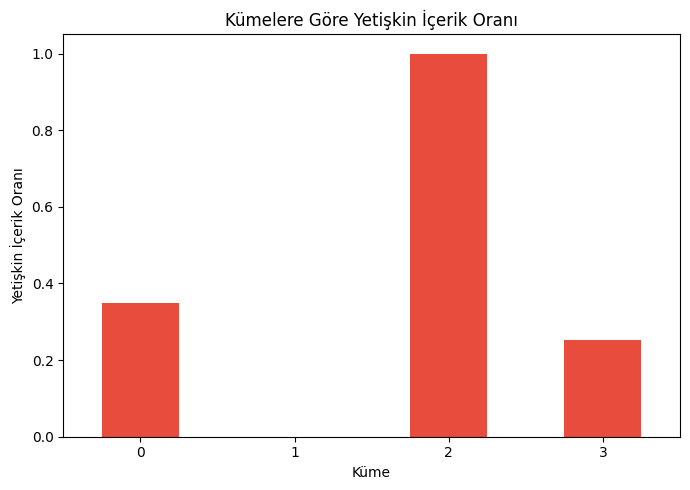

In [34]:
mature_ratio = (
    df_tv_clean
    .groupby("cluster")["is_mature"]
    .mean()
)

plt.figure(figsize=(7,5))
mature_ratio.plot(kind="bar", color="#e74c3c")

plt.ylabel("Yetişkin İçerik Oranı")
plt.xlabel("Küme")
plt.title("Kümelere Göre Yetişkin İçerik Oranı")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [35]:
for cluster_id in sorted(df_tv_clean["cluster"].unique()):
    print(f"\n🔹 Küme {cluster_id}")
    display(
        df_tv_clean[df_tv_clean["cluster"] == cluster_id][
            ["title", "num_seasons", "genre_count", "is_mature", "binge_score"]
        ].head(5)
    )



🔹 Küme 0


,title,num_seasons,genre_count,is_mature,binge_score
5,The Great British Baking Show,9,2,0,5.1
13,Resurrection: Ertugrul,5,3,0,3.4
25,Nailed It,6,1,0,3.3
26,Numberblocks,6,1,0,3.3
28,Saved by the Bell,9,2,0,5.1



🔹 Küme 1


,title,num_seasons,genre_count,is_mature,binge_score
12,Monsters Inside: The 24 Faces of Billy Milligan,1,3,0,1.4
14,Love on the Spectrum,2,3,0,1.9
19,Angry Birds,1,2,0,1.1
21,He-Man and the Masters of the Universe,1,2,0,1.1
24,Dharmakshetra,1,3,0,1.4



🔹 Küme 2


,title,num_seasons,genre_count,is_mature,binge_score
0,Blood & Water,2,3,1,2.1
1,Ganglands,1,3,1,1.6
2,Jailbirds New Orleans,1,2,1,1.3
3,Kota Factory,2,3,1,2.1
4,Midnight Mass,1,3,1,1.6



🔹 Küme 3


,title,num_seasons,genre_count,is_mature,binge_score
15,Chicago Party Aunt,1,1,1,1.0
18,Tayo and Little Wizards,1,1,0,0.8
20,Chhota Bheem,3,1,0,1.8
32,The World's Most Amazing Vacation Rentals,2,1,0,1.3
35,Metal Shop Masters,1,1,1,1.0


In [36]:
cluster_identity = cluster_summary.copy()
cluster_identity["Küme Yorumu"] = [
    "Uzun soluklu, yüksek binge potansiyeli",
    "Kısa, aile dostu içerikler",
    "Yetişkinlere yönelik yoğun diziler",
    "Tematik, düşük binge potansiyeli"
]

cluster_identity


,num_seasons,release_year,genre_count,is_mature,binge_score,Küme Yorumu
cluster,,,,,,
0,5.94,2014.72,2.24,0.35,3.71,"Uzun soluklu, yüksek binge potansiyeli"
1,1.29,2016.12,2.57,0.00,1.42,"Kısa, aile dostu içerikler"
2,1.36,2018.01,2.70,1.00,1.69,Yetişkinlere yönelik yoğun diziler
3,1.55,2015.82,1.00,0.25,1.12,"Tematik, düşük binge potansiyeli"


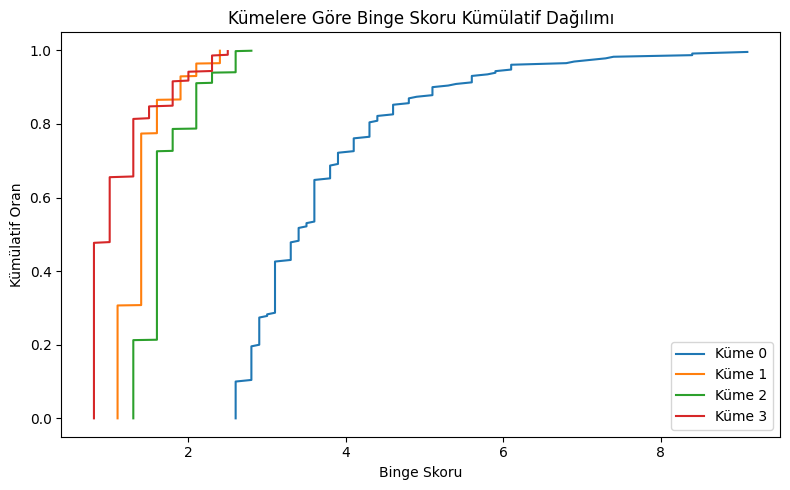

In [37]:
plt.figure(figsize=(8,5))

for c in sorted(df_tv_clean["cluster"].unique()):
    data = np.sort(df_tv_clean[df_tv_clean["cluster"] == c]["binge_score"])
    y = np.arange(len(data)) / len(data)
    plt.plot(data, y, label=f"Küme {c}")

plt.xlabel("Binge Skoru")
plt.ylabel("Kümülatif Oran")
plt.title("Kümelere Göre Binge Skoru Kümülatif Dağılımı")
plt.legend()
plt.tight_layout()
plt.show()
